In [63]:
import json, pandas as pd
from pathlib import Path

In [64]:
JSON_PATH = Path("../data/camera_trap_dataset_april/speciesnet_perbox.json")

with JSON_PATH.open() as f:
    frames = json.load(f)["predictions"]

In [83]:
rows = []
for frame in frames:
    ts   = frame.get("timestamp")                      # may be None if missing
    img  = Path(frame["filepath"]).name                # just the basename
    for det_idx, det in enumerate(frame["detections"]):
        classes = det["classifications"]["classes"]
        scores  = det["classifications"]["scores"]
        rows.append({
            "orig_image" : img,
            "bbox_idx"   : det_idx,
            "timestamp"  : ts,
            "bbox"       : det["bbox"],                # relative x,y,w,h
            "det_conf"   : det["conf"],
            "species"    : classes[0],                 # top-1
            "cls_conf"   : scores[0],
            "top5_labels": classes,                    # keep full lists
            "top5_scores": scores
        })

df = pd.DataFrame(rows)

print(f"Loaded {len(df)} detections from {len(frames)} frames.")

# filter by confidence
DET_TH   = 0.75
CLS_TH   = 0.4

df_filtered = (
    df[(df["det_conf"] > DET_TH) & (df["cls_conf"] > CLS_TH)]
      .reset_index(drop=True)
)

print(f"After filtering: {len(df_filtered)} detections remain "
      f"({len(df_filtered)/len(df):.1%} of total).")

df_filtered["species"] = df_filtered["species"].apply(short_label)
df_filtered.head()

Loaded 991 detections from 429 frames.
After filtering: 349 detections remain (35.2% of total).


,orig_image,bbox_idx,timestamp,bbox,det_conf,species,cls_conf,top5_labels,top5_scores
0,04010614.JPG,0,2025-04-01 18:50:45,"[0.3697916679084301, 0.32969433069229126, 0.09...",0.893752,mule deer,0.560910,[febff896-db40-4ac8-bcfe-5bb99a600950;mammalia...,"[0.560909628868103, 0.12132268399000168, 0.098..."
1,04010615.JPG,0,2025-04-01 18:50:46,"[0.34252452105283737, 0.18449782580137253, 0.0...",0.858434,european roe deer,0.905609,[317171d7-d306-4e71-9a4a-33e62012076b;mammalia...,"[0.9056094884872437, 0.042814530432224274, 0.0..."
2,04010623.JPG,0,2025-04-01 20:24:57,"[0.20159314572811127, 0.4022926092147827, 0.27...",0.953498,blank,0.624300,[f1856211-cfb7-4a5b-9158-c0f72fd09ee6;;;;;;bla...,"[0.6243001818656921, 0.03753385320305824, 0.02..."
3,04010624.JPG,0,2025-04-01 20:24:58,"[0.0, 0.4415939152240753, 0.4371936321258545, ...",0.934410,wild boar,0.993654,[d372cda5-a8ca-4b7b-97ed-4e4fab9c9b4b;mammalia...,"[0.9936540126800537, 0.0008738948381505907, 0...."
4,04010624.JPG,1,2025-04-01 20:24:58,"[0.41084559075534344, 0.32259825617074966, 0.0...",0.832379,wild boar,0.969019,[d372cda5-a8ca-4b7b-97ed-4e4fab9c9b4b;mammalia...,"[0.9690189361572266, 0.005982918664813042, 0.0..."


In [84]:
df_filtered[df_filtered["species"] == "blank"].count()

orig_image     70
bbox_idx       70
timestamp      70
bbox           70
det_conf       70
species        70
cls_conf       70
top5_labels    70
top5_scores    70
dtype: int64

In [85]:
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import numpy as np
from PIL import ImageFont


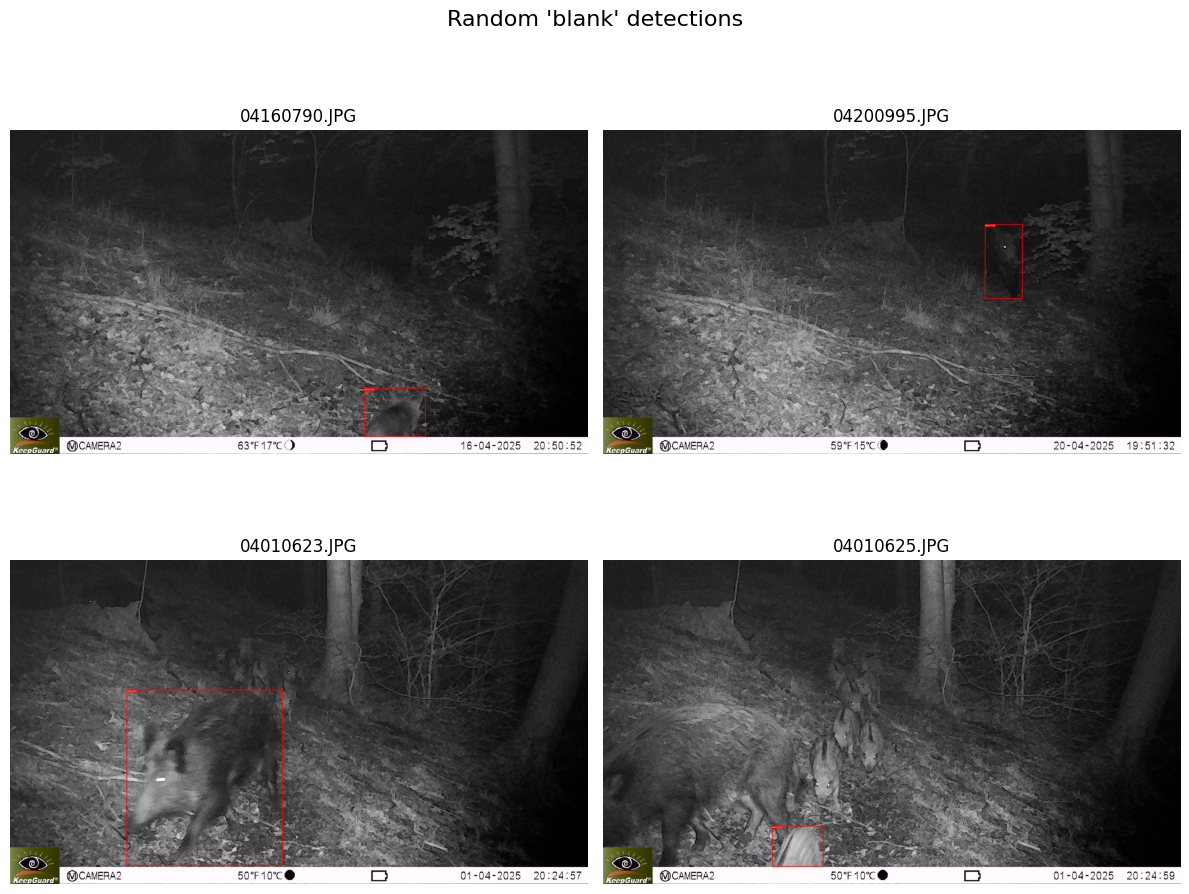

In [86]:
IMAGE_DIR = Path("../data/camera_trap_dataset_april/animal_images")  
N_SAMPLES = 4 
DET_COLOR = "red"
LABEL_BG  = "red"
LABEL_FG  = "white"

df_blanks = df_filtered[df_filtered["species"] == "blank"]


sample = df_blanks.sample(n=N_SAMPLES).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample.iterrows()):
    img_path = IMAGE_DIR / row["orig_image"]
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    W, H = img.size

    # ---- bbox --------------------------------------------------------
    x_rel, y_rel, w_rel, h_rel = map(float, row["bbox"])
    x0 = int(max(0, x_rel * W))
    y0 = int(max(0, y_rel * H))
    x1 = int(min(W, (x_rel + w_rel) * W))
    y1 = int(min(H, (y_rel + h_rel) * H))
    draw.rectangle([x0, y0, x1, y1], outline=DET_COLOR, width=4)

    # ---- label -------------------------------------------------------
    label = f"blank ({row['cls_conf']:.2f})"
    try:
        bx0, by0, bx1, by1 = draw.textbbox((0, 0), label)
        txt_w, txt_h = bx1 - bx0, by1 - by0
    except AttributeError:  # very old Pillow fallback
        txt_w, txt_h = FONT.getsize(label)

    pad = 2
    draw.rectangle([x0, y0, x0 + txt_w + 2*pad, y0 + txt_h + 2*pad],
                   fill=LABEL_BG)
    draw.text((x0 + pad, y0 + pad), label, fill=LABEL_FG)

    # ---- show --------------------------------------------------------
    ax.imshow(np.asarray(img))
    ax.set_title(row["orig_image"])
    ax.axis("off")

fig.suptitle("Random 'blank' detections", fontsize=16)
plt.tight_layout()

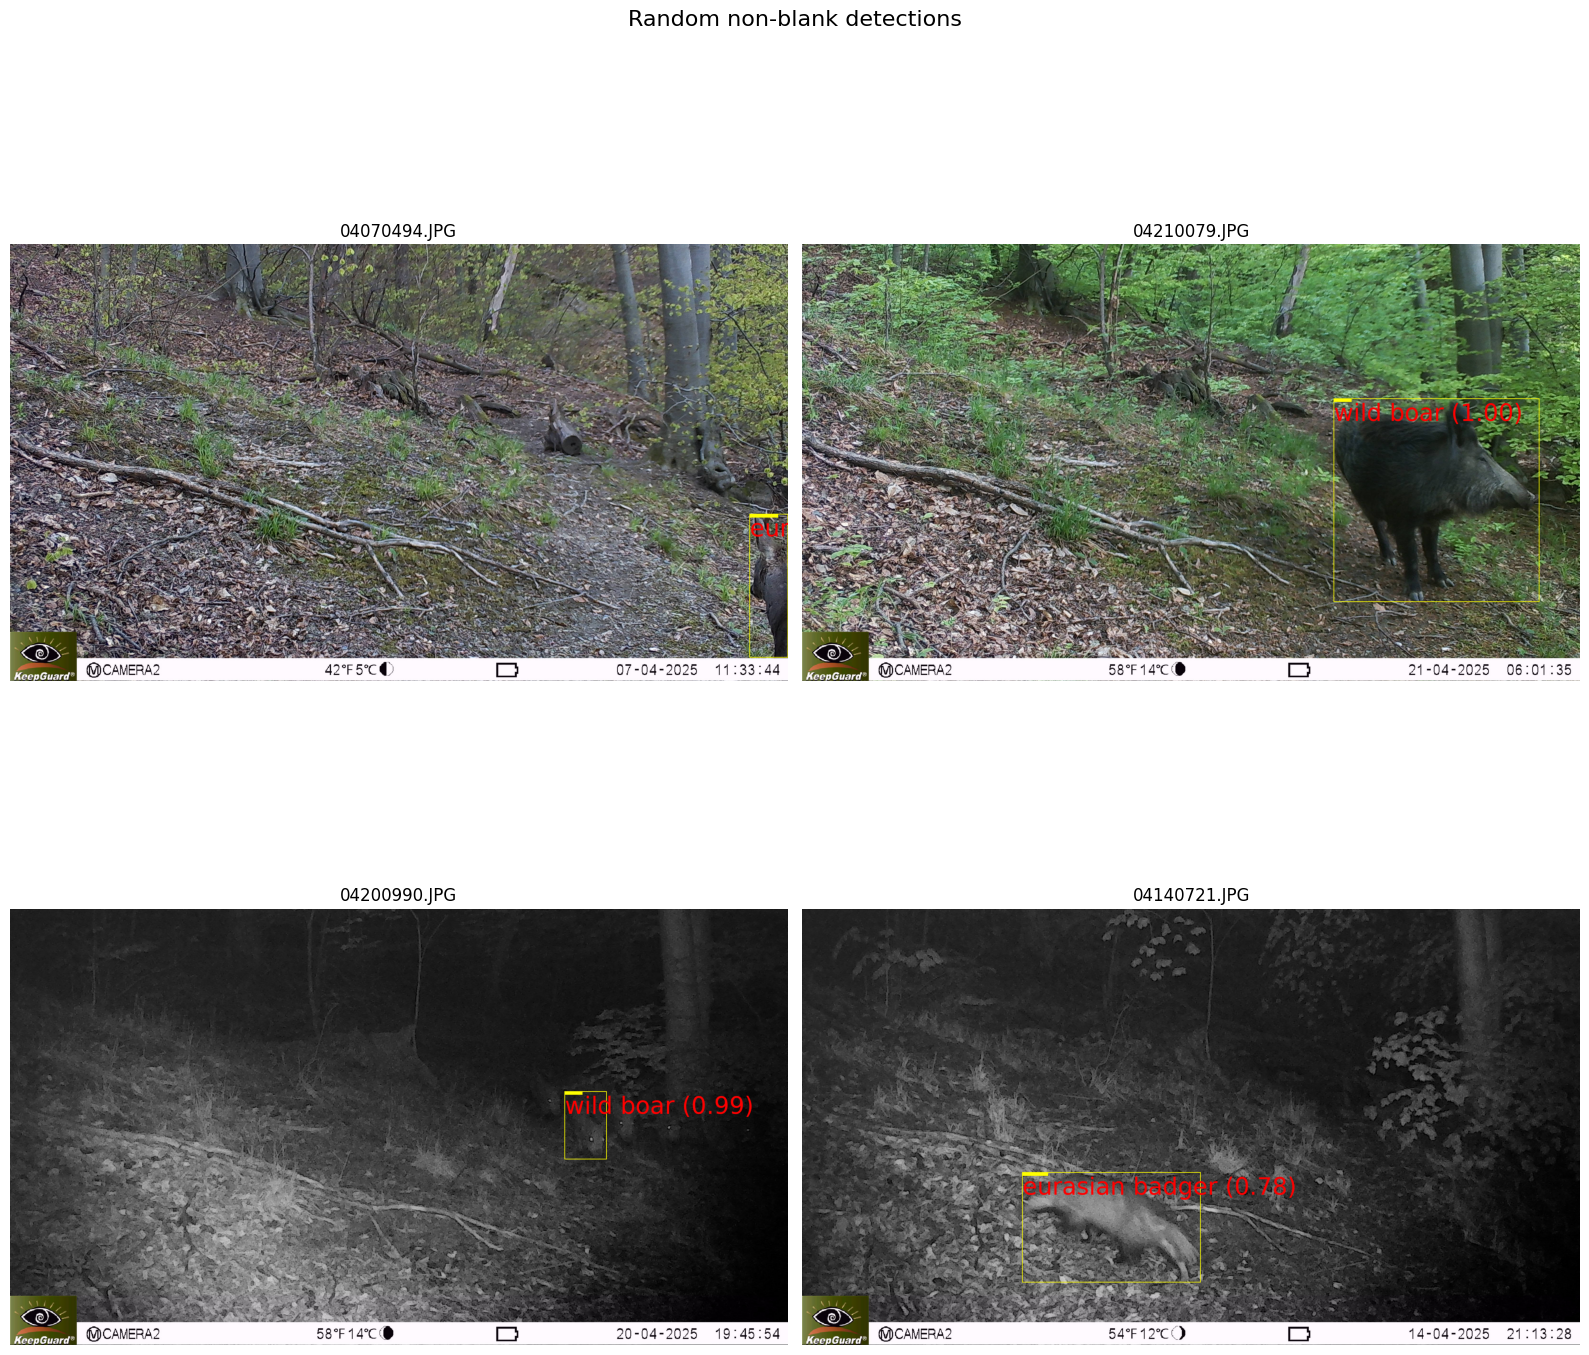

In [88]:
GRID_R, GRID_C = 2, 2
BOX_COLOR  = "yellow"
LINE_W     = 3
LABEL_BG   = "yellow"
LABEL_FG   = "red"
FONT = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 100)

# pick random non-blank detections
df_nonblank = df_filtered[df_filtered["species"] != "blank"]

sample = df_nonblank.sample(n=GRID_R * GRID_C).reset_index()

fig, axes = plt.subplots(GRID_R, GRID_C, figsize=(16, 16))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample.iterrows()):
    img_path = IMAGE_DIR / row["orig_image"]
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    W, H = img.size

    # bbox: relative → absolute, clip to bounds
    x_rel, y_rel, w_rel, h_rel = map(float, row["bbox"])
    x0 = int(max(0, x_rel * W))
    y0 = int(max(0, y_rel * H))
    x1 = int(min(W, (x_rel + w_rel) * W))
    y1 = int(min(H, (y_rel + h_rel) * H))

    draw.rectangle([x0, y0, x1, y1], outline=BOX_COLOR, width=LINE_W)

    # label text
    species = row["species"]
    label   = f"{species} ({row['cls_conf']:.2f})"

    lx0, ly0, lx1, ly1 = draw.textbbox((0, 0), label)
    txt_w, txt_h = lx1 - lx0, ly1 - ly0

    pad = 2
    draw.rectangle([x0, y0, x0 + txt_w + 2*pad, y0 + txt_h + 2*pad],
                   fill=LABEL_BG)
    draw.text((x0 + pad, y0 + pad), label, fill=LABEL_FG, font=FONT)

    # 6) show
    ax.imshow(np.asarray(img))
    ax.set_title(row["orig_image"])
    ax.axis("off")

fig.suptitle("Random non-blank detections", fontsize=16)
plt.tight_layout()

=== Detections by species ===


,species,detections,percent
0,wild boar,159,45.6
1,blank,70,20.1
2,european roe deer,41,11.7
3,red fox,26,7.4
4,bird,10,2.9
5,eurasian red squirrel,10,2.9
6,eurasian badger,8,2.3
7,mule deer,6,1.7
8,white-tailed deer,4,1.1
9,european hare,4,1.1


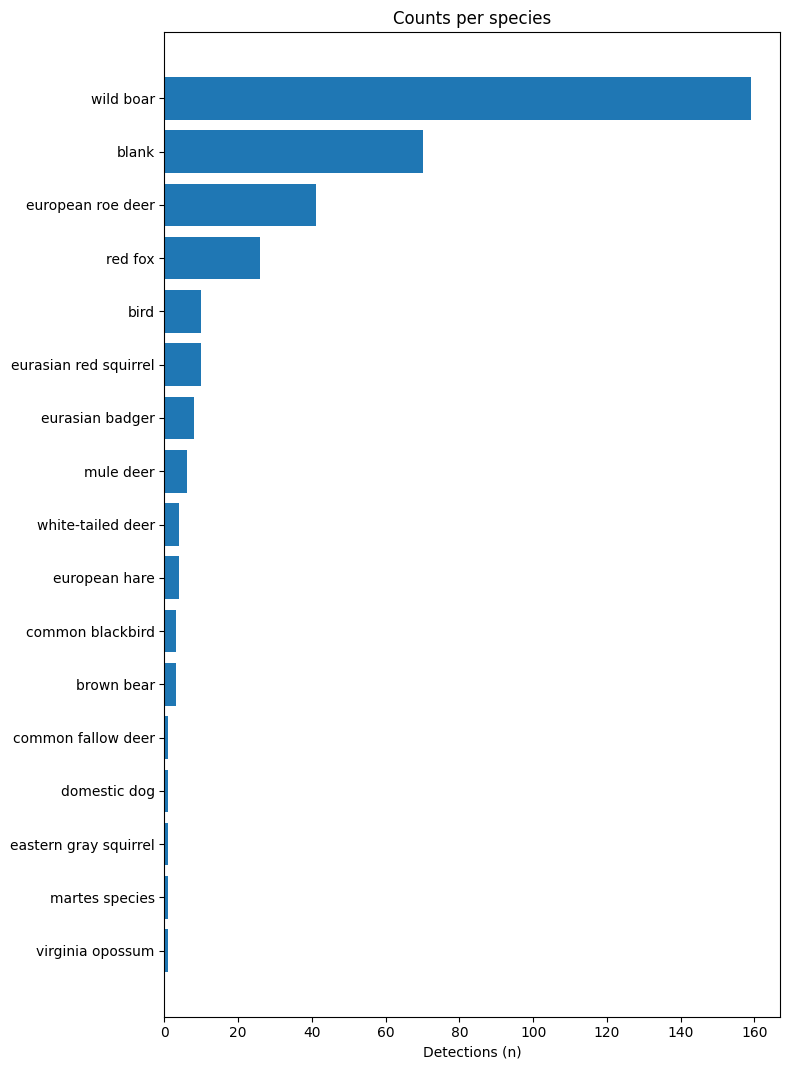

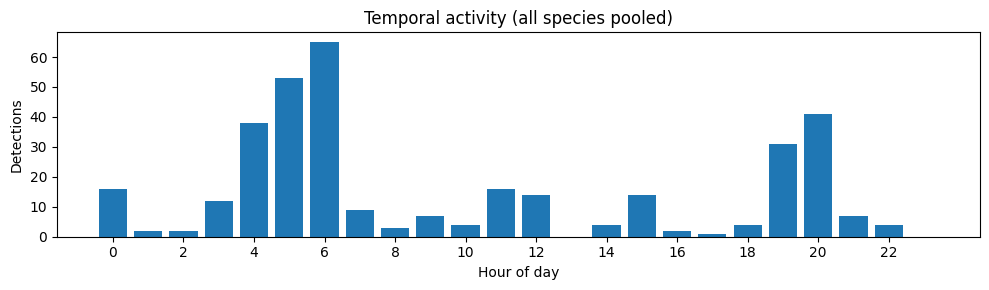

In [89]:
# -----------------------------------------------------------------------------------
# 1. COUNTS PER SPECIES
# -----------------------------------------------------------------------------------
species_counts = (
    df_filtered["species"]
      .value_counts()
      .rename_axis("species")
      .reset_index(name="detections")
)

species_counts["percent"] = 100 * species_counts["detections"] / species_counts["detections"].sum()
species_counts_round = species_counts.copy()
species_counts_round["percent"] = species_counts_round["percent"].round(1)

print("=== Detections by species ===")
display(species_counts_round)

# -----------------------------------------------------------------------------------
# 2. BAR CHART
# -----------------------------------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4 + 0.4 * len(species_counts)))
plt.barh(species_counts["species"], species_counts["detections"])
plt.xlabel("Detections (n)")
plt.title("Counts per species")
plt.gca().invert_yaxis()  # largest on top
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------------
# 3. 24-H ACTIVITY HISTOGRAM (all species)
# -----------------------------------------------------------------------------------
# parse timestamp column to pandas datetime (if you haven't already)
df_filtered["timestamp"] = pd.to_datetime(df_filtered["timestamp"], errors="coerce")

df_hour = (
    df_filtered.dropna(subset=["timestamp"])
               .assign(hour=lambda x: x["timestamp"].dt.hour)
               .groupby("hour")
               .size()
               .reindex(range(24), fill_value=0)
)

plt.figure(figsize=(10, 3))
plt.bar(df_hour.index, df_hour.values, width=0.8)
plt.xticks(range(0, 24, 2))
plt.xlabel("Hour of day")
plt.ylabel("Detections")
plt.title("Temporal activity (all species pooled)")
plt.tight_layout()
plt.show()


=== Top-4 species summary ===


,detections,frames,mean_det_conf,mean_cls_conf,detections_pct
species,,,,,
wild boar,159,146,0.934,0.949,53.7
blank,70,65,0.850,0.909,23.6
european roe deer,41,41,0.952,0.904,13.9
red fox,26,26,0.903,0.914,8.8


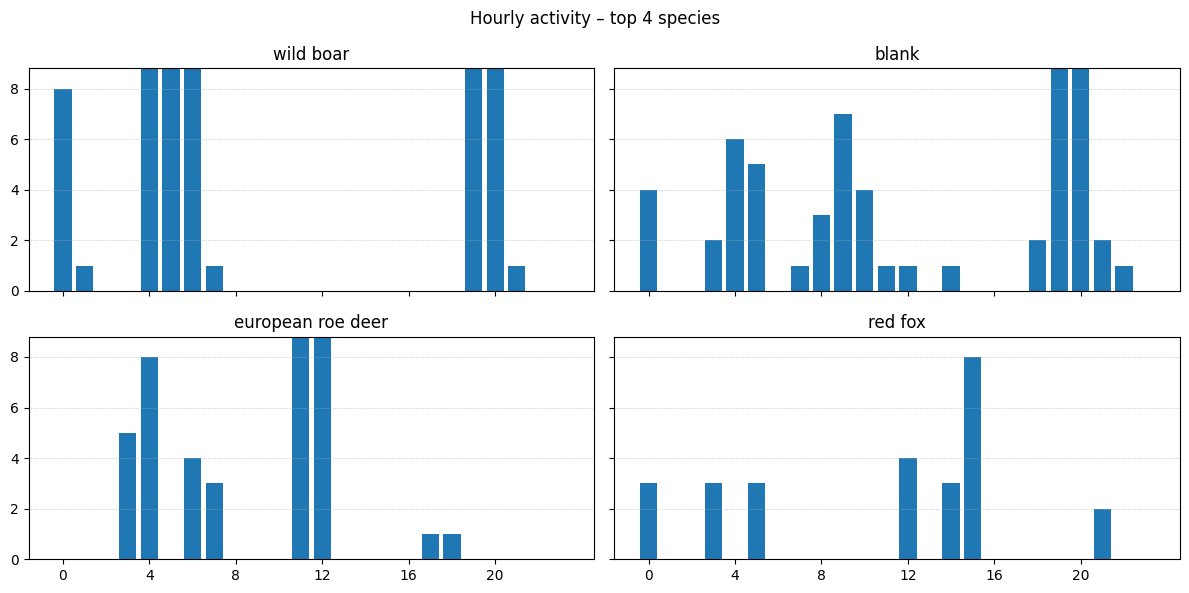

<Figure size 800x400 with 0 Axes>

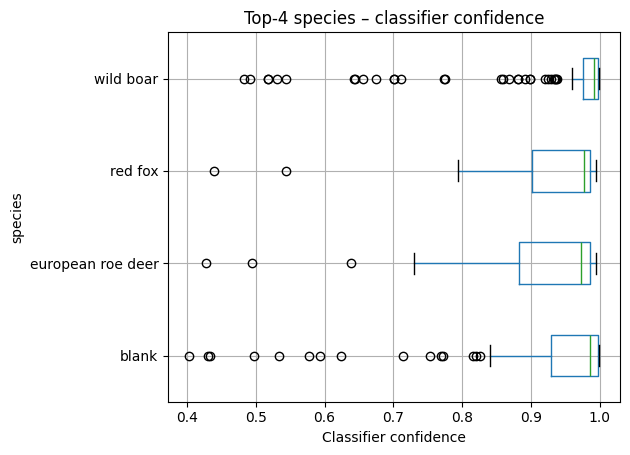

In [90]:
# -----------------------------------------------------------------------------------
# CONFIG – adjust if you want >4 species
TOP_N = 4
# -----------------------------------------------------------------------------------

# 1 ── choose top-N species
top_species = species_counts.head(TOP_N)["species"].tolist()
df_top = df_filtered[df_filtered["species"].isin(top_species)].copy()

# 2 ── basic stats
stats = (
    df_top
    .groupby("species")
    .agg(
        detections   = ("species", "size"),
        frames       = ("orig_image", "nunique"),
        mean_det_conf= ("det_conf", "mean"),
        mean_cls_conf= ("cls_conf", "mean")
    )
    .sort_values("detections", ascending=False)
)
stats["detections_pct"] = (100 * stats["detections"] / stats["detections"].sum()).round(1)
stats["mean_det_conf"]  = stats["mean_det_conf"].round(3)
stats["mean_cls_conf"]  = stats["mean_cls_conf"].round(3)

print("=== Top-4 species summary ===")
display(stats)

# 3 ── DETECTIONS BY HOUR, one subplot per species
import matplotlib.pyplot as plt

df_top["timestamp"] = pd.to_datetime(df_top["timestamp"], errors="coerce")
df_top = df_top.dropna(subset=["timestamp"])
df_top["hour"] = df_top["timestamp"].dt.hour

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True)
axes = axes.flatten()

for ax, sp in zip(axes, top_species):
    counts = df_top[df_top["species"] == sp]["hour"].value_counts().reindex(range(24), fill_value=0)
    ax.bar(counts.index, counts.values, width=0.8)
    ax.set_title(sp)
    ax.set_xticks(range(0, 24, 4))
    ax.set_ylim(0, counts.values.max() * 1.1)
    ax.grid(axis='y', linestyle=":", lw=0.5)

fig.suptitle("Hourly activity – top 4 species")
plt.tight_layout()
plt.show()

# 4 ── CLASSIFIER CONFIDENCE BOXPLOT
plt.figure(figsize=(8,4))
df_top.boxplot(column="cls_conf", by="species", vert=False)
plt.xlabel("Classifier confidence")
plt.title("Top-4 species – classifier confidence")
plt.suptitle("")
plt.tight_layout()
plt.show()
